# Chapter 13 Lab — Fundamental MRI Physics (Python)

MRI is built on a handful of equations you can explore directly: exponential relaxation, a simple signal equation, and the Fourier transform. In this lab we follow a four-step arc:

1. **Plot T1 recovery and T2 decay curves** for gray matter, white matter, and CSF
2. **Use the signal equation** to see how TR and TE control which tissue property dominates the image
3. **Render a digital head phantom** as proton-density-, T1-, and T2-weighted images
4. **Explore k-space**: transform an image to spatial frequencies and back, and see what the center and edges of k-space each contribute

Because everything is simulated, you can change any constant — a tissue's T1, the echo time, a k-space mask — and immediately see the consequences.

**How to run this notebook.** Run it in your browser from the tutorial site, in Google Colab, or in a local Jupyter installation. It uses only `numpy` and `matplotlib`, and all data are simulated — nothing to download. It accompanies the [chapter page](../ch13-fundamental-mri-physics.md).

*Portions adapted from the CANlab tutorial "Lab 1: T1 decay and basic MATLAB" (canlab.github.io).*

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=3, suppress=True)
print("numpy", np.__version__)

numpy 2.4.6


## Step 1 — T1 recovery and T2 decay

After an RF pulse tips the net magnetization into the transverse plane, the system relaxes back to equilibrium along two separable dimensions:

- **Longitudinal (T1) relaxation** — recovery of magnetization along $B_0$:
  $M_z(t) = M_0\,(1 - e^{-t/T_1})$
- **Transverse (T2) relaxation** — decay of the rotating transverse magnetization as spins dephase:
  $M_{xy}(t) = M_0\, e^{-t/T_2}$

Both are exponential curves built on Euler's number $e \approx 2.718$. That choice of base is where the famous "63%" comes from: at $t = T_1$ the recovery curve reaches $1 - 1/e \approx 0.63$, and at $t = T_2$ the decay curve has fallen to $1/e \approx 0.37$.

Each tissue type has its own time constants. We will use round, illustrative values (in milliseconds), along with relative proton (water) densities $\rho$:

| Tissue | T1 (ms) | T2 (ms) | $\rho$ (relative) |
|---|---|---|---|
| Gray matter | 1000 | 100 | 0.85 |
| White matter | 600 | 80 | 0.70 |
| CSF | 3000 | 2000 | 1.00 |

1/e = 0.36787944117144233


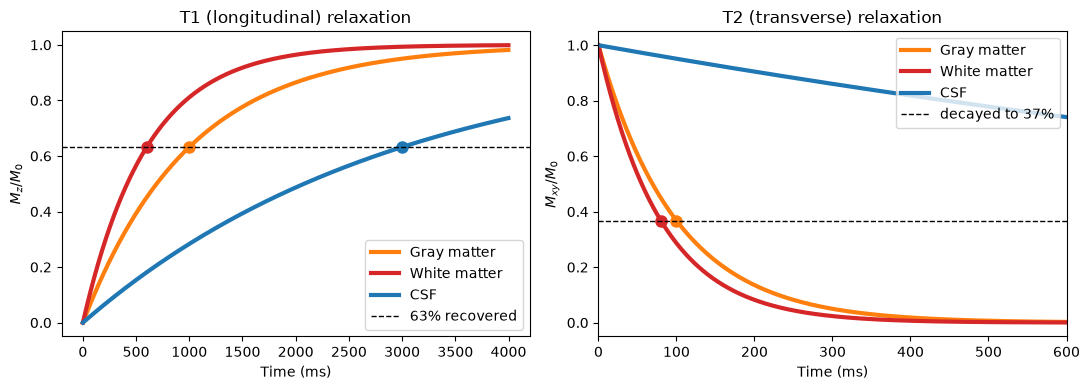

In [2]:
print("1/e =", 1 / np.e)          # the origin of the 37% / 63% rule

# Tissue constants: T1 (ms), T2 (ms), relative proton density rho
tissues = {
    "Gray matter":  dict(T1=1000, T2=100,  rho=0.85, color="tab:orange"),
    "White matter": dict(T1=600,  T2=80,   rho=0.70, color="tab:red"),
    "CSF":          dict(T1=3000, T2=2000, rho=1.00, color="tab:blue"),
}

t1relax = lambda t, T1: 1 - np.exp(-t / T1)   # longitudinal recovery
t2decay = lambda t, T2: np.exp(-t / T2)       # transverse decay

t = np.arange(0, 4000.0)                      # time after excitation (ms)

fig, (axL, axR) = plt.subplots(1, 2, figsize=(11, 4))
for name, p in tissues.items():
    axL.plot(t, t1relax(t, p["T1"]), lw=3, color=p["color"], label=name)
    axL.plot(p["T1"], 1 - 1/np.e, "o", ms=8, color=p["color"])
    axR.plot(t, t2decay(t, p["T2"]), lw=3, color=p["color"], label=name)
    axR.plot(p["T2"], 1/np.e, "o", ms=8, color=p["color"])

axL.axhline(1 - 1/np.e, color="k", ls="--", lw=1, label="63% recovered")
axL.set(xlabel="Time (ms)", ylabel="$M_z / M_0$",
        title="T1 (longitudinal) relaxation")
axL.legend(loc="lower right")

axR.axhline(1/np.e, color="k", ls="--", lw=1, label="decayed to 37%")
axR.set(xlabel="Time (ms)", ylabel="$M_{xy} / M_0$", xlim=(0, 600),
        title="T2 (transverse) relaxation")
axR.legend(loc="upper right")
plt.tight_layout()

Each curve crosses the dashed line exactly at its own time constant (dots): white matter recovers longitudinal magnetization fastest and CSF slowest, while in the transverse plane gray and white matter dephase within a few hundred milliseconds and CSF holds its signal far longer.

The key insight for imaging: **at any single readout time, the tissues sit at different heights on their curves.** That vertical separation *is* tissue contrast — and the scanner's timing parameters control where on the curves we sample.

## Step 2 — The signal equation: how TR and TE create contrast

A pulse sequence excites the spins every **TR** milliseconds (repetition time) and reads out the signal **TE** milliseconds after each excitation (echo time). For a basic sequence, the measured signal from a tissue is approximately

$$S = \rho \left(1 - e^{-TR/T_1}\right) e^{-TE/T_2}$$

- The first factor is how much longitudinal magnetization has *recovered* since the last excitation (T1 term, controlled by TR).
- The second factor is how much transverse signal *remains* at readout (T2 term, controlled by TE).
- $\rho$ is the proton density — the number of hydrogen nuclei contributing.

Three classic parameter regimes follow:

| Choice | T1 term | T2 term | Result |
|---|---|---|---|
| long TR, short TE | ≈ 1 for all tissues | ≈ 1 for all tissues | **proton-density** image |
| intermediate TR, short TE | *differs* across tissues | ≈ 1 | **T1-weighted** image |
| long TR, intermediate TE | ≈ 1 | *differs* across tissues | **T2-weighted** image |

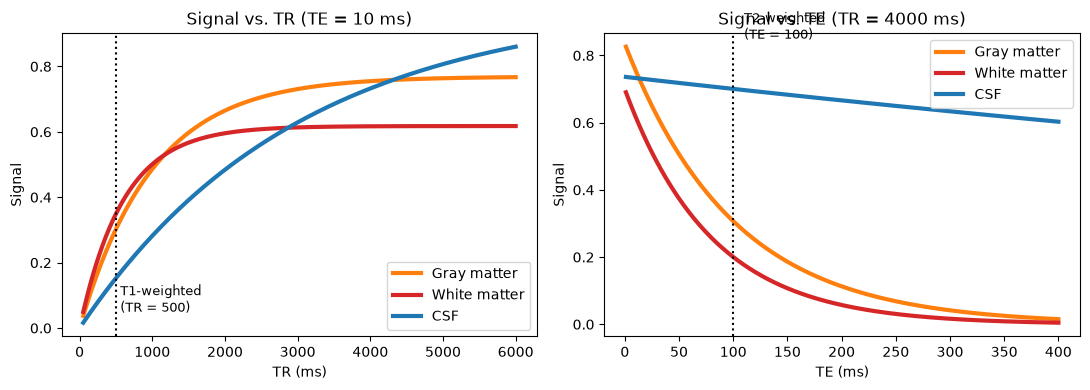

In [3]:
def signal(TR, TE, T1, T2, rho):
    # Basic MR signal equation: recovered longitudinal x remaining transverse
    return rho * (1 - np.exp(-TR / T1)) * np.exp(-TE / T2)

TRs = np.linspace(50, 6000, 400)
TEs = np.linspace(1, 400, 400)

fig, (axL, axR) = plt.subplots(1, 2, figsize=(11, 4))
for name, p in tissues.items():
    axL.plot(TRs, signal(TRs, 10, p["T1"], p["T2"], p["rho"]),
             lw=3, color=p["color"], label=name)
    axR.plot(TEs, signal(4000, TEs, p["T1"], p["T2"], p["rho"]),
             lw=3, color=p["color"], label=name)

axL.axvline(500, color="k", ls=":", lw=1.5)
axL.text(560, 0.05, "T1-weighted\n(TR = 500)", fontsize=9)
axL.set(xlabel="TR (ms)", ylabel="Signal", title="Signal vs. TR (TE = 10 ms)")
axL.legend(loc="lower right")

axR.axvline(100, color="k", ls=":", lw=1.5)
axR.text(110, 0.85, "T2-weighted\n(TE = 100)", fontsize=9)
axR.set(xlabel="TE (ms)", ylabel="Signal", title="Signal vs. TE (TR = 4000 ms)")
axR.legend(loc="upper right")
plt.tight_layout()

Read the two panels like a scanner operator:

- **Left (varying TR, short TE).** At short-to-intermediate TR, tissues are separated by their T1 recovery — white matter (short T1) has recovered most, CSF (long T1) least, so **white > gray > CSF**: T1 weighting. As TR grows, every tissue recovers fully and the curves converge toward the proton densities.
- **Right (varying TE, long TR).** At short TE little has decayed and tissues differ mainly by proton density. At intermediate TE, gray and white matter (short T2) have lost most of their signal while CSF (very long T2) has not, so **CSF ≫ gray > white**: T2 weighting.

## Step 3 — A digital head phantom in three contrasts

Now let's see these choices as *images*. We build a simple "head" from ellipses — a gray-matter shell, a white-matter interior, and two CSF-filled lateral ventricles — then assign each voxel its tissue's $T_1$, $T_2$, and $\rho$ and evaluate the signal equation at three (TR, TE) settings.

Setting            Gray matter  White matter           CSF
Proton density           0.755         0.617         0.733
T1-weighted              0.303         0.349         0.153
T2-weighted              0.307         0.200         0.700


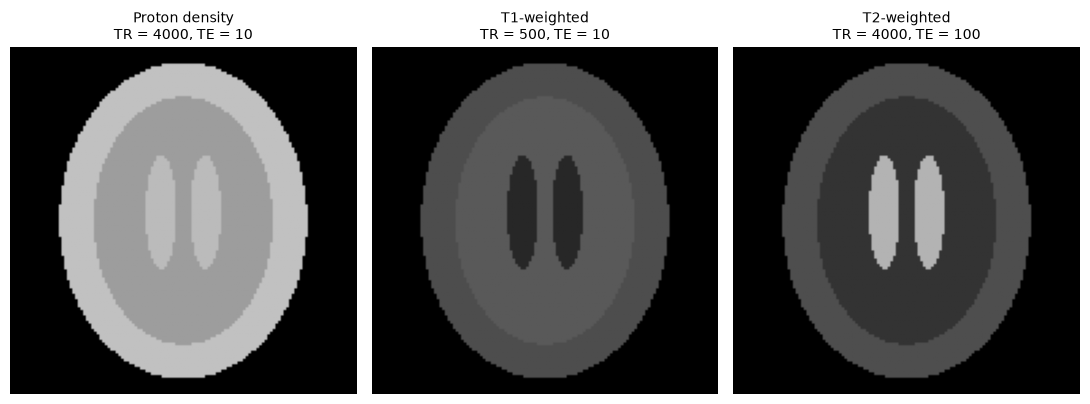

In [4]:
n = 128
yy, xx = np.mgrid[-1:1:n*1j, -1:1:n*1j]

def ellipse(cx, cy, ax_r, ay_r):
    return ((xx - cx) / ax_r) ** 2 + ((yy - cy) / ay_r) ** 2 < 1

# Tissue label map: 0 = background, then gray shell, white interior, ventricles
labels = np.zeros((n, n), dtype=int)
label_names = {1: "Gray matter", 2: "White matter", 3: "CSF"}
labels[ellipse(0, 0, 0.72, 0.92)] = 1            # gray-matter shell
labels[ellipse(0, 0, 0.52, 0.72)] = 2            # white-matter interior
labels[ellipse(-0.13, -0.05, 0.09, 0.33)] = 3    # left ventricle (CSF)
labels[ellipse(+0.13, -0.05, 0.09, 0.33)] = 3    # right ventricle (CSF)

tissue_of_label = {1: "Gray matter", 2: "White matter", 3: "CSF"}

def weighted_image(TR, TE):
    img = np.zeros((n, n))
    for lab, tname in tissue_of_label.items():
        p = tissues[tname]
        img[labels == lab] = signal(TR, TE, p["T1"], p["T2"], p["rho"])
    return img

settings = [("Proton density\nTR = 4000, TE = 10",  4000, 10),
            ("T1-weighted\nTR = 500, TE = 10",      500,  10),
            ("T2-weighted\nTR = 4000, TE = 100",    4000, 100)]

fig, axes = plt.subplots(1, 3, figsize=(11, 4))
for ax, (title, TR, TE) in zip(axes, settings):
    ax.imshow(weighted_image(TR, TE), cmap="gray", vmin=0, vmax=1)
    ax.set_title(title, fontsize=10)
    ax.axis("off")
plt.tight_layout()

# Signal values per tissue at each setting
print(f"{'Setting':<16}" + "".join(f"{t:>14}" for t in tissues))
for title, TR, TE in settings:
    vals = [signal(TR, TE, p['T1'], p['T2'], p['rho'])
            for p in tissues.values()]
    print(f"{title.splitlines()[0]:<16}" + "".join(f"{v:>14.3f}" for v in vals))

The same "brain," three different pictures — compare them with the real PD/T1/T2 images on the chapter page:

- **Proton density**: all tissues bright and similar; contrast reflects only water content.
- **T1-weighted**: white matter brightest, gray matter intermediate, ventricles dark — the classic anatomical scan.
- **T2-weighted**: the ventricles glow while white matter goes dark. This is also why pathology with increased water content (edema, inflammation, tumors) lights up on clinical T2-weighted scans.

Try it: edit `settings` to make TR very short *and* TE long. You will get a dim, low-contrast image — you have suppressed the signal with both factors at once, which is why that combination is never used.

## Step 4 — k-space: images as sums of spatial frequencies

The scanner never measures an image directly. Gradient coils impose controlled field variations so that each measurement equals the **2D Fourier transform** of the slice at one spatial frequency $(k_x, k_y)$ — one point in **k-space**. After sampling enough of k-space (line by line in EPI), an inverse FFT reconstructs the image.

Since the FT is perfectly reversible, we can do the same thing in reverse: take our phantom into k-space with `np.fft.fft2` and look at what lives where.

Fraction of k-space energy inside the center disk (r < 10): 0.971


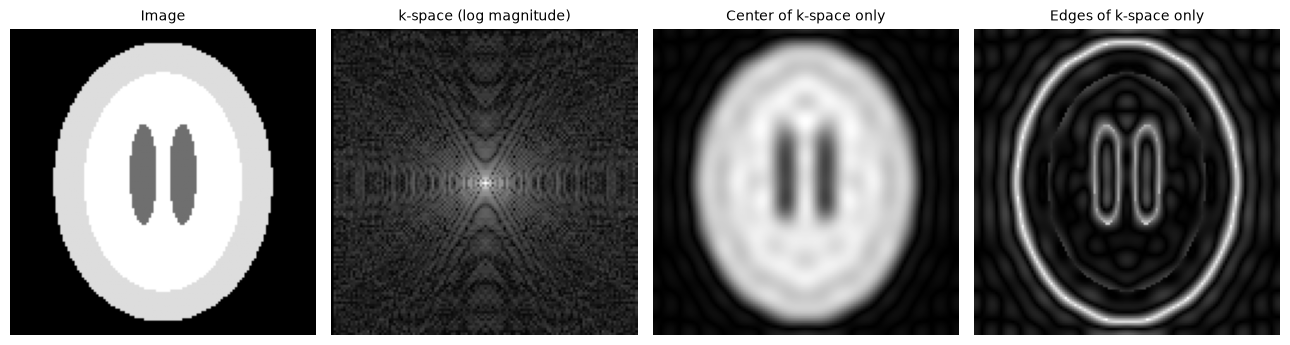

In [5]:
img = weighted_image(500, 10)                  # the T1-weighted phantom

F = np.fft.fftshift(np.fft.fft2(img))          # image -> k-space (center at middle)
kyy, kxx = np.mgrid[-n//2:n//2, -n//2:n//2]
k_radius = np.sqrt(kxx**2 + kyy**2)

center_mask = k_radius < 10                    # low spatial frequencies only
edges_mask = ~center_mask                      # high spatial frequencies only

def recon(Fmasked):
    return np.abs(np.fft.ifft2(np.fft.ifftshift(Fmasked)))

panels = [
    (img,                    "Image",                    None),
    (np.log1p(np.abs(F)),    "k-space (log magnitude)",  None),
    (recon(F * center_mask), "Center of k-space only",   None),
    (recon(F * edges_mask),  "Edges of k-space only",    None),
]
fig, axes = plt.subplots(1, 4, figsize=(13, 3.4))
for ax, (im, title, _) in zip(axes, panels):
    ax.imshow(im, cmap="gray")
    ax.set_title(title, fontsize=10)
    ax.axis("off")
plt.tight_layout()

frac = np.sum(np.abs(F[center_mask])**2) / np.sum(np.abs(F)**2)
print(f"Fraction of k-space energy inside the center disk (r < 10): {frac:.3f}")

Three things to notice:

1. **k-space is brightest at its center.** The vast majority of the image's energy lives in a few low spatial frequencies (check the printed fraction).
2. **Center only → a blurry but recognizable brain.** Low spatial frequencies carry overall shape and contrast. This is why motion during the sampling of central k-space lines is so damaging: it corrupts the gross structure of the whole image.
3. **Edges only → just the outlines.** High spatial frequencies carry fine detail: tissue boundaries, small structures, sharpness.

Every k-space point spreads across the *entire* image. To see this directly, let's build "images" containing only a single spatial frequency.

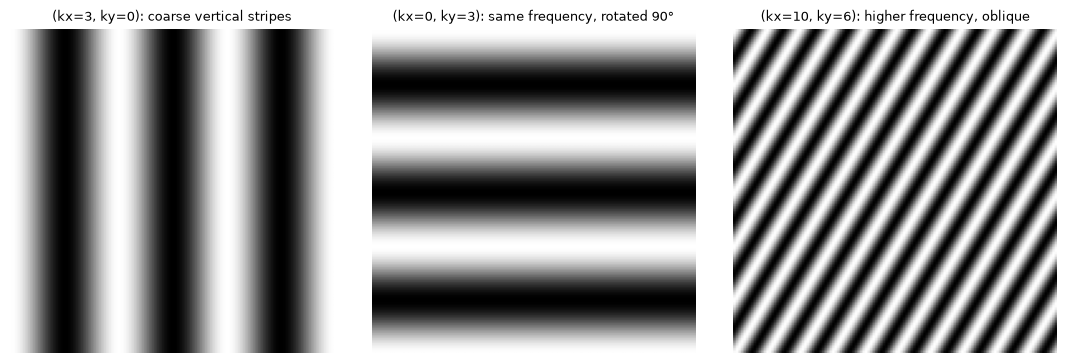

In [6]:
def single_point_image(kx, ky):
    # k-space that is zero except one point and its conjugate mirror
    Fp = np.zeros((n, n), dtype=complex)
    Fp[n//2 + ky, n//2 + kx] = 1
    Fp[n//2 - ky, n//2 - kx] = 1               # conjugate symmetry -> real image
    return np.real(np.fft.ifft2(np.fft.ifftshift(Fp)))

examples = [(3, 0, "(kx=3, ky=0): coarse vertical stripes"),
            (0, 3, "(kx=0, ky=3): same frequency, rotated 90°"),
            (10, 6, "(kx=10, ky=6): higher frequency, oblique")]

fig, axes = plt.subplots(1, 3, figsize=(11, 3.6))
for ax, (kx, ky, title) in zip(axes, examples):
    ax.imshow(single_point_image(kx, ky), cmap="gray")
    ax.set_title(title, fontsize=9)
    ax.axis("off")
plt.tight_layout()

Each single k-space point is a 2D sinusoid filling the whole field of view. Its **distance** from the k-space center sets the stripe frequency, and its **polar angle** sets the stripe orientation — the first two examples are equidistant from the origin, so their stripes have the same spacing but are rotated 90° from each other. A real image is nothing more than a weighted sum of thousands of these gratings, and reconstruction (the inverse FFT) is just the bookkeeping that adds them up.

## Summary

- T1 recovery and T2 decay are exponentials with tissue-specific time constants; the "63%" rule follows from the base $e$.
- The signal equation $S = \rho(1 - e^{-TR/T_1})e^{-TE/T_2}$ shows how TR and TE select which tissue property dominates: long TR + short TE → proton density, intermediate TR + short TE → T1-weighted, long TR + intermediate TE → T2-weighted.
- Images are acquired in k-space, one spatial frequency at a time; the center carries gross structure and most of the energy, the periphery carries fine detail, and the inverse Fourier transform assembles the image.
- T2*-weighted images use similar timing to T2-weighted ones but are additionally sensitive to field inhomogeneities from deoxyhemoglobin — the bridge to BOLD physiology in Chapter 14.